In [14]:
"""
Bond albedo calculation using pre-computed single-scattering albedos.

Loads omega(lambda) directly from VAYU's surface library, forms the
directional-hemispherical reflectance r_dh(lambda, mu0) via Hammond Eq. 4,
integrates over the dayside with cos-weighting (proper Bond geometry),
and weights by the stellar spectrum.

Note: VAYU's omega(lambda) values follow the Hammond et al. (2025) code
recipe, omega = 1 - R^2 (see spectral.py), rather than a formal Hapke
inversion of the RELAB reflectance factor.
"""

import numpy as np
from pathlib import Path


# ---------- Hapke pipeline ----------

def dayside_integrated_reflectance(omega, n_mu=200):
    """Dayside-integrated directional-hemispherical reflectance.

    Computes Hammond Eq. 4,

        r_dh(lambda, mu0) = (1 - gamma(lambda)) / (1 + 2 * gamma(lambda) * mu0),

    and integrates over incidence cosine mu0 in [0, 1] with cos-weighting
    (i.e. spherical/Bond geometry):

        r_dayside(lambda) = int_0^1 r_dh(lambda, mu0) * 2 * mu0 dmu0.
    """
    gamma = np.sqrt(1.0 - omega)
    mu0 = np.linspace(1e-3, 1.0, n_mu)
    r_dh = (1.0 - gamma)[:, None] / (1.0 + 2.0 * gamma[:, None] * mu0[None, :])
    return np.trapezoid(r_dh * 2.0 * mu0[None, :], mu0, axis=1)


# ---------- Bond albedo ----------

def bond_albedo(wl, reflectance, wl_star, flux_star, wl_min=None, wl_max=None):
    """Stellar-flux-weighted reflectance integrated over wavelength."""
    flux_interp = np.interp(wl, wl_star, flux_star)
    mask = np.ones_like(wl, dtype=bool)
    if wl_min is not None:
        mask &= wl >= wl_min
    if wl_max is not None:
        mask &= wl <= wl_max
    num = np.trapezoid(reflectance[mask] * flux_interp[mask], wl[mask])
    den = np.trapezoid(flux_interp[mask], wl[mask])
    return num / den


# ---------- Run ----------

surfdir = Path("../res/surfaces/")
stardir = Path("../res/stellar_spectra/")

# Single-scattering albedo from VAYU's surface library
wl_omega, omega = np.loadtxt(surfdir / "hematite.dat", unpack=True)
wl_omega = wl_omega / 1000.0   # nm -> μm; remove if file already in μ

# Stellar spectrum
wl_star, flux_star = np.loadtxt(stardir / "trappist-1.txt", unpack=True) 
wl_star = wl_star / 1000.0     # nm -> μm
wl_star = wl_star 

# Pipeline: omega -> r_dh dayside integration -> Bond albedo
r_dayside = dayside_integrated_reflectance(omega)
A_B = bond_albedo(wl_omega, r_dayside, wl_star, flux_star)

print(f"Hematite Bond albedo under TRAPPIST-1: {A_B:.3f}")

Hematite Bond albedo under TRAPPIST-1: 0.362


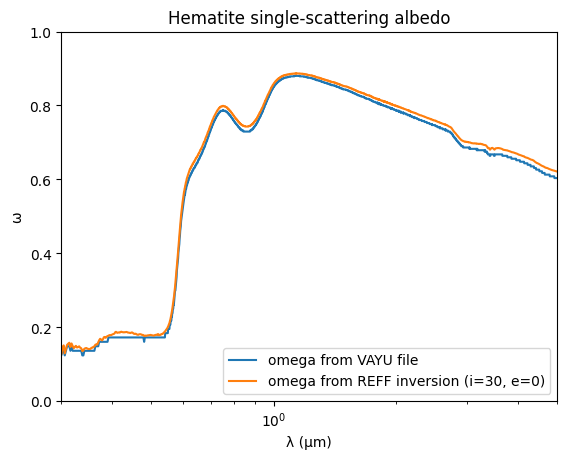

In [2]:
# After the run block, add:
from scipy.optimize import brentq

def H_two_stream(x, gamma):
    return (1.0 + 2.0 * x) / (1.0 + 2.0 * gamma * x)

def rdd_from_omega(omega, mu0=np.cos(np.radians(0)), mu=1.0):
    gamma = np.sqrt(1.0 - omega)
    return (omega / (4.0 * np.pi)) * (mu0 / (mu0 + mu)) * H_two_stream(mu0, gamma) * H_two_stream(mu, gamma)

def invert_omega_from_reff(reff):
    target = reff / np.pi
    out = np.zeros_like(reff)
    for i, t in enumerate(target):
        if t <= 0: continue
        try: out[i] = brentq(lambda w: rdd_from_omega(w) - t, 1e-6, 1 - 1e-6)
        except ValueError: out[i] = 1.0
    return out

wl_refl, refl = np.loadtxt("../res/surfaces/raw/96_hematite_fs.tab", delimiter=",", unpack=True)
refl = np.clip(refl, 0, None)
omega_from_inv = invert_omega_from_reff(refl)

import matplotlib.pyplot as plt
plt.semilogx(wl_omega, omega, label="omega from VAYU file")
plt.semilogx(wl_refl, omega_from_inv, label="omega from REFF inversion (i=30, e=0)")
plt.xlim(0.3, 5); plt.ylim(0, 1); plt.xlabel("λ (μm)"); plt.ylabel("ω")
plt.legend(); plt.title("Hematite single-scattering albedo")
plt.show()

In [ ]:
"""
Bond albedo replication following the Hammond et al. (2025) code path:
emission.py for the dayside integration + spectral.py for the
single-scattering-albedo recipe.

Recipe (from the public code, not the published equations):
  - omega = 1 - R^2, where R is the raw RELAB reflectance factor
    (spectral.py: `w = np.clip(1.0 - surface.reflectance**2, 0, 1)`).
    Note: this is NOT a Hapke inversion of REFF, despite what the
    methods section of the paper describes.
  - Stellar spectrum: blackbody at T_eff (emission.py uses planck()).
  - Dayside integration on a 6 x 6 (lon, lat) grid spanning -pi/2 to pi/2,
    with cos^2 weighting (one cosine via the local flux factor, one via
    dA_proj). The substellar point is not sampled on this symmetric grid.
"""

import numpy as np
from pathlib import Path

# ---------- Constants ----------
H_PLANCK = 6.62607015e-34   # J s
C_LIGHT  = 2.99792458e8      # m/s
K_BOLTZ  = 1.380649e-23      # J/K
RSUN     = 6.957e8           # m
AU       = 1.495978707e11    # m

# ---------- Surface ----------
rawdir = Path("../res/surfaces/raw/")
wl_refl, refl = np.loadtxt(rawdir / "96_hematite_fs.tab", delimiter=",", unpack=True)
refl = np.clip(refl, 0.0, None)   # wavelength in microns

# ---------- Stellar / planetary parameters (TRAPPIST-1) ----------
T_STAR = 2566.0     # K
R_STAR = 0.1192     # solar radii
A_AU   = 0.01154    # semi-major axis; the dilution factor cancels in the
                    # reflected/incident ratio, but keep it for consistency.

# ---------- Blackbody stellar spectrum (Hammond-style) ----------
def planck_per_wavelength_micron(wl_um, T):
    """B_lambda in W/m^2/sr/micron for wavelength in microns."""
    wl_m = wl_um * 1.0e-6
    exponent = H_PLANCK * C_LIGHT / (wl_m * K_BOLTZ * T)
    B = (2.0 * H_PLANCK * C_LIGHT**2) / (wl_m**5) / (np.exp(exponent) - 1.0)
    return B * 1.0e-6   # per metre -> per micron

flux_star = planck_per_wavelength_micron(wl_refl, T_STAR)
flux_star_at_planet = flux_star * (R_STAR * RSUN / (A_AU * AU))**2

# Wavelength bin widths (used as `wid` in Hammond's code)
wid = np.empty_like(wl_refl)
wid[1:-1] = 0.5 * (wl_refl[2:] - wl_refl[:-2])
wid[0]    = wl_refl[1]  - wl_refl[0]
wid[-1]   = wl_refl[-1] - wl_refl[-2]

# ---------- Single-scattering albedo, Hammond-recipe (spectral.py) ----------
# w = clip(1 - R^2, 0, 1); note this is *not* a Hapke inversion of REFF.
omega = np.clip(1.0 - refl**2, 0.0, 1.0)
gamma = np.sqrt(np.clip(1.0 - omega, 0.0, None))

# ---------- Dayside integration (Hammond's 6 x 6 grid) ----------
grid_points = 6
longitudes = np.linspace(-np.pi/2, np.pi/2, grid_points)
latitudes  = np.linspace(-np.pi/2, np.pi/2, grid_points)

total_reflected = 0.0
total_incident  = 0.0

for lon in longitudes:
    for lat in latitudes:
        cos_sza = np.cos(lon) * np.cos(lat)
        if cos_sza <= 0:
            continue
        mu0     = cos_sza
        dA      = np.cos(lat)        # area element on the sphere
        dA_proj = dA * cos_sza       # "projected area" used in their accumulation

        # r_h at this local zenith (Hammond Eq. 4)
        r_h = (1.0 - gamma) / (1.0 + 2.0 * gamma * mu0)

        # Local per-wavelength stellar flux at this point
        stellar = mu0 * flux_star_at_planet * wid

        # Local sums over wavelength
        local_reflected = np.sum(stellar * r_h)
        local_incident  = np.sum(stellar)

        # Global accumulation with the extra cos_sza via dA_proj
        total_reflected += local_reflected * dA_proj
        total_incident  += local_incident  * dA_proj

A_B_hammond_style = total_reflected / total_incident
print(f"Hematite 'Effective albedo' under TRAPPIST-1 (Hammond-style): {A_B_hammond_style:.3f}")

Hematite 'Effective albedo' under TRAPPIST-1 (Hammond-style): 0.555
